In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import product
from tqdm import tqdm
import math
import os
from collections import defaultdict
from typing import Dict, List, Union

import os

# Variables

In [2]:
# Train Headway (min)
train_headway_list = [10, 20, 30]

# MoD Fleet Size
mod_fleet_size_list = [30, 50, 70, 90, 110, 130, 150]

# MaaS Platform Communication Strategy
maas_communication_strategy_list = ['default', 'TPCS']

# Random Seed
random_seed_list = [3, 6, 9]

# MoD Waiting Time Threshold (s)
mod_waiting_time_threshold_list = [300, 600, 900]
# MoD Detour Time Threshold (%)
mod_detour_time_threshold_list = [30, 60, 90]

# Demand Size
demand_size_list = [i for i in range(100, 1001, 100)]
# Demand Split Ratio (Intra Modal, %)
demand_split_ratio_list = [0, 20, 40, 60, 80]

# Total Simulation Time (s)
total_sim_time = [0, 10800]  # 3 hours
# Warm-up Time (s)
warmup_time = 3600  # 1 hour
# Simulation Time Period (s)
time_period = [warmup_time, total_sim_time[1]+warmup_time]  # 1h + 3h

name_dict = {
    'random_seed': "Random Seed", 
    'fleet_size': "Fleet Size",
    'demand_size': "Demand Size",
    'intra_ratio': "Intra Demand Ratio",
    'op_max_detour_time_factor': "Max Detour Time Factor",
    'op_max_wait_time': "Max Wait Time",
    'train_headway': "Train Headway",
    'average_journey_time': "Average Journey Time",
    'average_intercity_journey_time': "Average Intercity Journey Time",
    'average_intracity_journey_time': "Average Intracity Journey Time",
    'average_journey_time_extended': "Average Journey Time (Extended)",
    'average_intercity_journey_time_extended': "Average Intercity Journey Time (Extended)",
    'average_intracity_journey_time_extended': "Average Intracity Journey Time (Extended)",
    'average_amod_service_rate': "Average AMoD Service Rate",
    'total_amod_cost': "Total AMoD Cost",
    'broker_type': "MaaS Communication Strategy",
    'fleet_utilization_rate': "Fleet Utilization Rate",
}

amod_simulation_results_folder = r"D:\projects\fleetpy\github\ptbroker\studies\j26-tpcs\results"

# Tools

In [3]:
def get_boarding_vehicles_at_pos(
    file_path: str, 
    target_pos_id: Union[str, int], 
    target_operator_id: Union[str, int]
) -> Dict[int, List[str]]:
    
    boarding_schedule = defaultdict(list)
    
    target_pos_id = str(target_pos_id)
    target_operator_id = str(target_operator_id)

    if not os.path.exists(file_path):
        print(f"Cannot find file: {file_path}")
        return {}

    try:
        df = pd.read_csv(file_path)
        
        df['operator_id'] = df['operator_id'].astype(str)
        df['status'] = df['status'].astype(str)
        df['start_pos'] = df['start_pos'].astype(str)

        mask = (df['operator_id'] == target_operator_id) & (df['status'] == 'boarding')
        filtered_df = df[mask].copy()

        if filtered_df.empty:
            return {}

        # Delete '-1;-1'
        filtered_df['pos_id_parsed'] = filtered_df['start_pos'].str.split(';').str[0]
        
        # Filter by position ID
        target_df = filtered_df[filtered_df['pos_id_parsed'] == target_pos_id]

        # Iterate over the filtered data and expand the time intervals
        for _, row in target_df.iterrows():
            try:
                veh_id = str(row['vehicle_id'])
                start_time = int(float(row['start_time']))
                end_time = int(float(row['end_time']))
                
                for t in range(start_time, end_time + 1):
                    boarding_schedule[t].append(veh_id)
                    
            except (ValueError, TypeError):
                print(f"Error, escape - Vehicle: {row.get('vehicle_id')}")
                continue

    except Exception as e:
        print(f"Error reading or processing file: {e}")
        return {}

    return dict(boarding_schedule)

# Get Vehicle Position Dictionary

In [4]:
# All scenario combinations
all_scenario_combinations = list(product(
    random_seed_list,
    mod_fleet_size_list,
    demand_size_list,
    demand_split_ratio_list,
    maas_communication_strategy_list,
    mod_detour_time_threshold_list,
    mod_waiting_time_threshold_list,
    train_headway_list
))

In [5]:
# all_mobility_hub_boarding_records = {}

# for scenario_combination in tqdm(all_scenario_combinations):
#     (
#         random_seed,
#         fleet_size,
#         demand_size,
#         demand_split_ratio,
#         broker_type,
#         op_max_detour_time_factor,
#         op_max_wait_time,
#         train_headway
#     ) = scenario_combination

#     scenario_name = f"amod-{demand_size}-{demand_split_ratio}-{fleet_size}-{broker_type}-{op_max_detour_time_factor}-{op_max_wait_time}-{train_headway}-{random_seed}-{time_period[0]}-{time_period[1]}"

#     vehicle_trajectory_filepath = os.path.join(amod_simulation_results_folder, scenario_name, '2-0_op-stats.csv')

#     left_mobility_hub_boarding_records = get_boarding_vehicles_at_pos(vehicle_trajectory_filepath, 120, 0)
#     right_mobility_hub_boarding_records = get_boarding_vehicles_at_pos(vehicle_trajectory_filepath, 241, 0)

#     # Use multiple keys to store both left and right hub records
#     all_mobility_hub_boarding_records[(
#         random_seed,
#         fleet_size,
#         demand_size,
#         demand_split_ratio,
#         broker_type,
#         op_max_detour_time_factor,
#         op_max_wait_time,
#         train_headway,
#         'left')] = left_mobility_hub_boarding_records
#     all_mobility_hub_boarding_records[(
#         random_seed,
#         fleet_size,
#         demand_size,
#         demand_split_ratio,
#         broker_type,
#         op_max_detour_time_factor,
#         op_max_wait_time,
#         train_headway,
#         'right')] = right_mobility_hub_boarding_records

In [6]:
import pickle

# Save the boarding records dictionary to a file
save_path = os.path.join(r'data\amod-sim-results', 'all_mobility_hub_boarding_records.pkl')

# with open(save_path, 'wb') as f:
#     pickle.dump(all_mobility_hub_boarding_records, f)

# Load the boarding records dictionary from a file
with open(save_path, 'rb') as f:
    data_records = pickle.load(f)

# Draw Distribution

In [7]:
BIN_SIZE = 60  # seconds
START_TIME = 0  # seconds
END_TIME = 6*3600  # seconds

In [8]:
# Convert dict to DataFrame for easier analysis
all_mobility_hub_boarding_records = []

for key_tuple, time_dict in tqdm(data_records.items()):
    (
        random_seed,
        fleet_size,
        demand_size,
        demand_split_ratio,
        broker_type,
        op_max_detour_time_factor,
        op_max_wait_time,
        train_headway,
        location_type
    ) = key_tuple
    
    scenario_signature = (
            f"{random_seed}-{fleet_size}-{demand_size}-{demand_split_ratio}-"
            f"{broker_type}-{op_max_detour_time_factor}-{op_max_wait_time}-"
            f"{train_headway}-{location_type}"
        )

    rows = []
    for time_sec, veh_list in time_dict.items():
        for veh_id in veh_list:
            rows.append({
                'time_sec': time_sec,
                'vehicle_id': veh_id,
            })
    df = pd.DataFrame(rows)
    df['time_bin'] = (df['time_sec'] // BIN_SIZE) * BIN_SIZE
    df_deduplicated = df.drop_duplicates(subset=['vehicle_id', 'time_bin'])
    # calculate vehicle counts per time bin
    vehicle_counts = df_deduplicated.groupby('time_bin')['vehicle_id'].count().to_dict()
    
    time_bins = list(range(START_TIME, END_TIME + BIN_SIZE, BIN_SIZE))
    # Create empty DataFrame to store all scenario records
    mobility_hub_boarding_record_dict = {}
    for bin_start in time_bins:
        mobility_hub_boarding_record_dict[f"time-bin-{bin_start}"] = vehicle_counts.get(bin_start, 0)
    mobility_hub_boarding_record_dict.update({
                'random_seed': random_seed,
                'fleet_size': fleet_size,
                'demand_size': demand_size,
                'demand_split_ratio': demand_split_ratio,
                'broker_type': broker_type,
                'op_max_detour_time_factor': op_max_detour_time_factor,
                'op_max_wait_time': op_max_wait_time,
                'train_headway': train_headway,
                'location_type': location_type,
                'scenario_signature': scenario_signature,
            })
    all_mobility_hub_boarding_records.append(mobility_hub_boarding_record_dict)

# Convert to DataFrame
all_mobility_hub_boarding_records_df = pd.DataFrame(all_mobility_hub_boarding_records)

100%|██████████| 113400/113400 [06:00<00:00, 314.56it/s]


In [ ]:
# # Save to CSV
# output_csv_path = os.path.join(r'data\amod-sim-results', 'all_mobility_hub_boarding_records.csv')
# all_mobility_hub_boarding_records_df.to_csv(output_csv_path, index=False)

# Tool

In [10]:
def plot_vehicle_counts(df, target_headway):
    filtered_df = df[df['train_headway'] == target_headway].copy()

    time_bin_columns = [col for col in filtered_df.columns if col.startswith('time-bin-')]
    
    id_vars = ['location_type', 'broker_type', 'train_headway', 'random_seed']
    
    df_long = pd.melt(
        filtered_df, 
        id_vars=id_vars, 
        value_vars=time_bin_columns,
        var_name='time_bin_str', 
        value_name='vehicle_count'
    )
    
    import re
    df_long['time_sec'] = df_long['time_bin_str'].apply(lambda x: int(re.search(r'\d+', x).group()))
    
    df_long['time_min'] = df_long['time_sec'] / 60

    sns.set_theme(style="whitegrid")
    
    g = sns.relplot(
        data=df_long,
        x="time_sec", 
        y="vehicle_count",
        col="broker_type", 
        row="location_type",
        kind="line",
        hue="broker_type",  
        style="location_type", 
        height=3.5, 
        aspect=1.8,
        estimator='sum',     
        errorbar=None,       
        col_order=['TPCS', 'default'], 
        row_order=['left', 'right'],
        linewidth=2
    )

    g.fig.suptitle(f'Vehicle Counts Over Time (Headway: {target_headway}s)', y=1.05, fontsize=16)
    
    g.set_axis_labels("Simulation Time (seconds)", "Total Vehicle Count")
    
    g.set_titles(col_template="Broker: {col_name}", row_template="Location: {row_name}")

    plt.show()

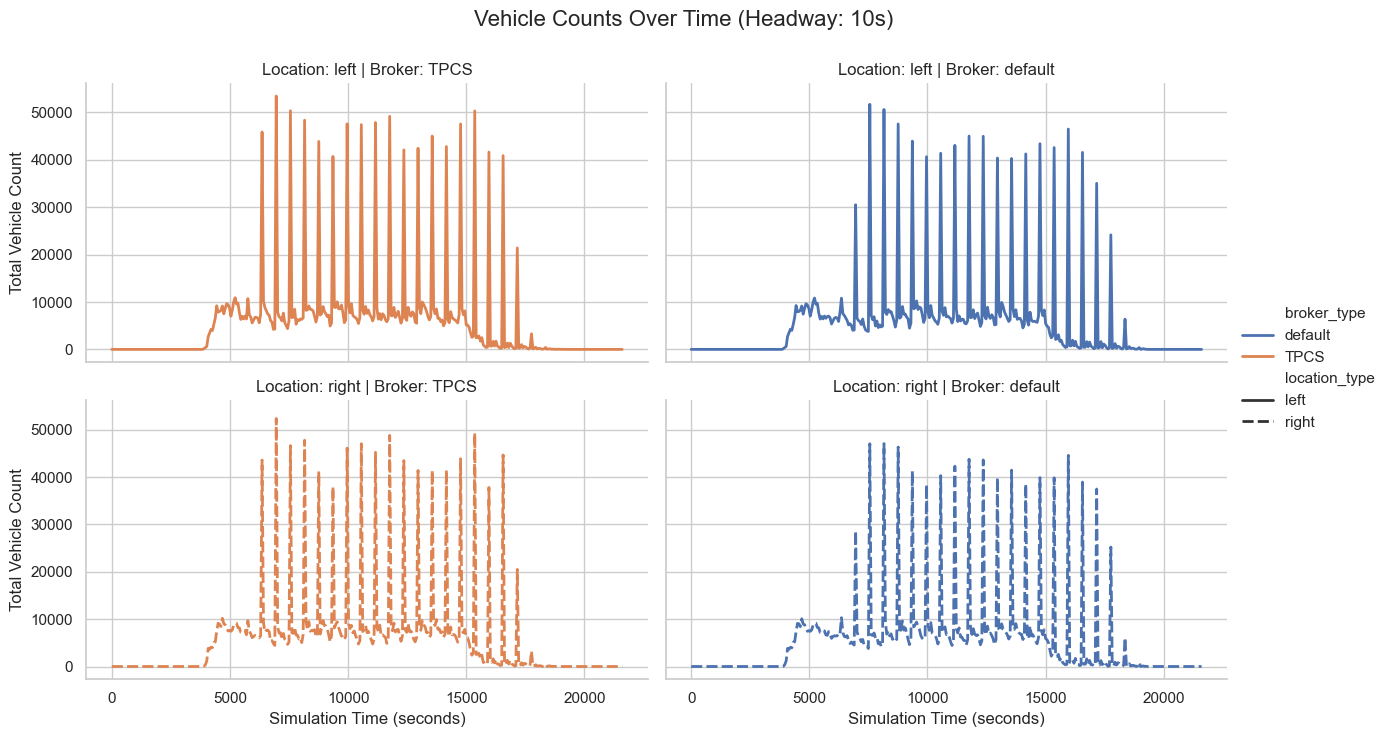

In [11]:
plot_vehicle_counts(df=all_mobility_hub_boarding_records_df, target_headway=10)

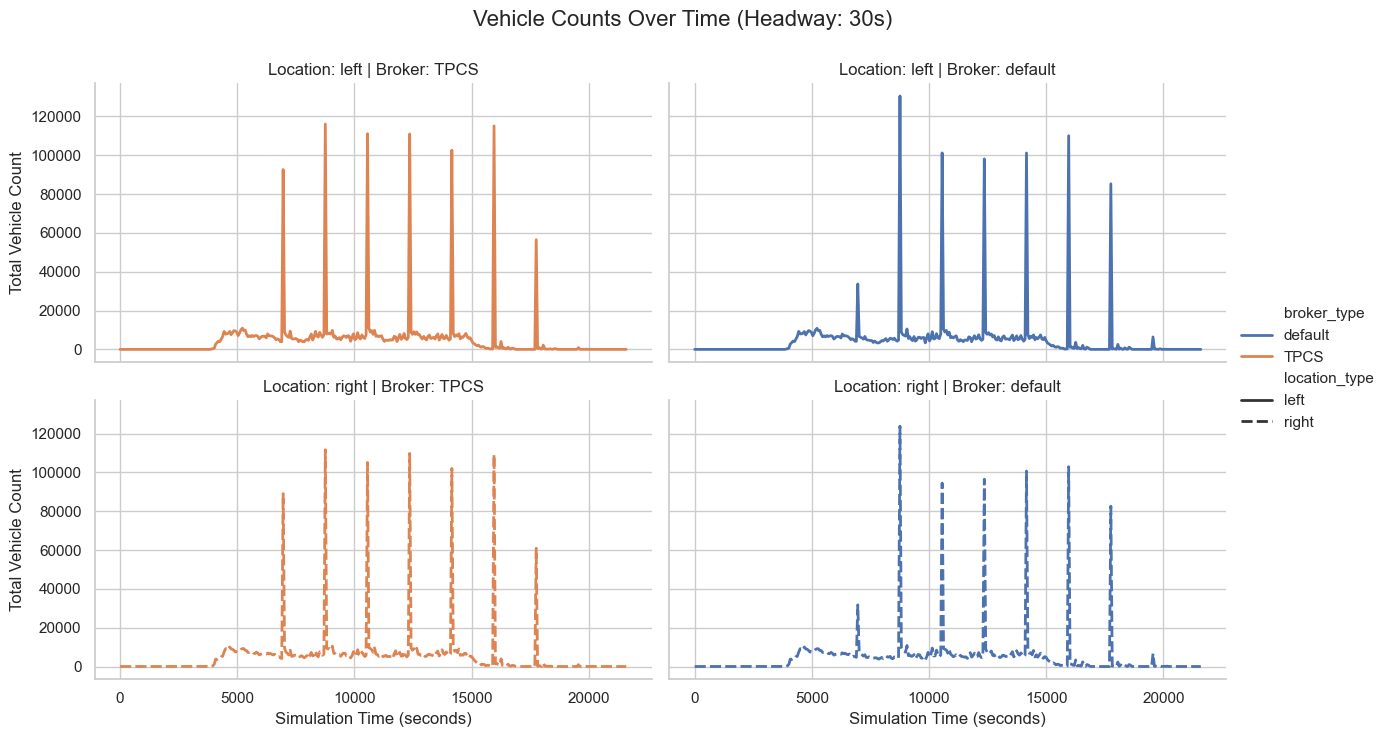

In [12]:
plot_vehicle_counts(df=all_mobility_hub_boarding_records_df, target_headway=30)